In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.dpi": 600,
    "figure.figsize": (6, 2.5),
    "font.size": 8,
    "mathtext.fontset": "stix"
})

In [2]:
active_passive_dict = np.load('vmem_amp_data_active_passive_bbp.npy', allow_pickle=True).item()

In [3]:
selected_cells = ['L4_BP_bIR215_5', "L5_MC_bAC217_1", "L5_TTPC2_cADpyr232_3", "L5_NGC_bNAC219_5", 'L4_SS_cADpyr230_1']

cell_cdm_colors = {
    'L4_BP_bIR215_5': "tab:orange",
    "L5_MC_bAC217_1": "tab:blue",
    "L5_TTPC2_cADpyr232_3": "tab:green",
    "L5_NGC_bNAC219_5": 'tab:red',
    'L4_SS_cADpyr230_1': 'tab:purple'
}

cell_base = {
    'L4_BP_bIR215_5': {'name': 'L4 BP', 'color_passive': 'tab:grey', 'color_active': 'tab:orange'},
    'L5_MC_bAC217_1': {'name': 'L5 MC', 'color_passive': 'tab:cyan', 'color_active': 'tab:blue'},
    'L5_TTPC2_cADpyr232_3': {'name': 'L5', 'color_passive': 'tab:olive', 'color_active': 'tab:green'},
    'L5_NGC_bNAC219_5': {'name': 'L5 NGC', 'color_passive': 'tab:brown', 'color_active': 'tab:red'},
    'L4_SS_cADpyr230_1': {'name': 'L4 SS', 'color_passive': 'tab:pink', 'color_active': 'tab:purple'},
}

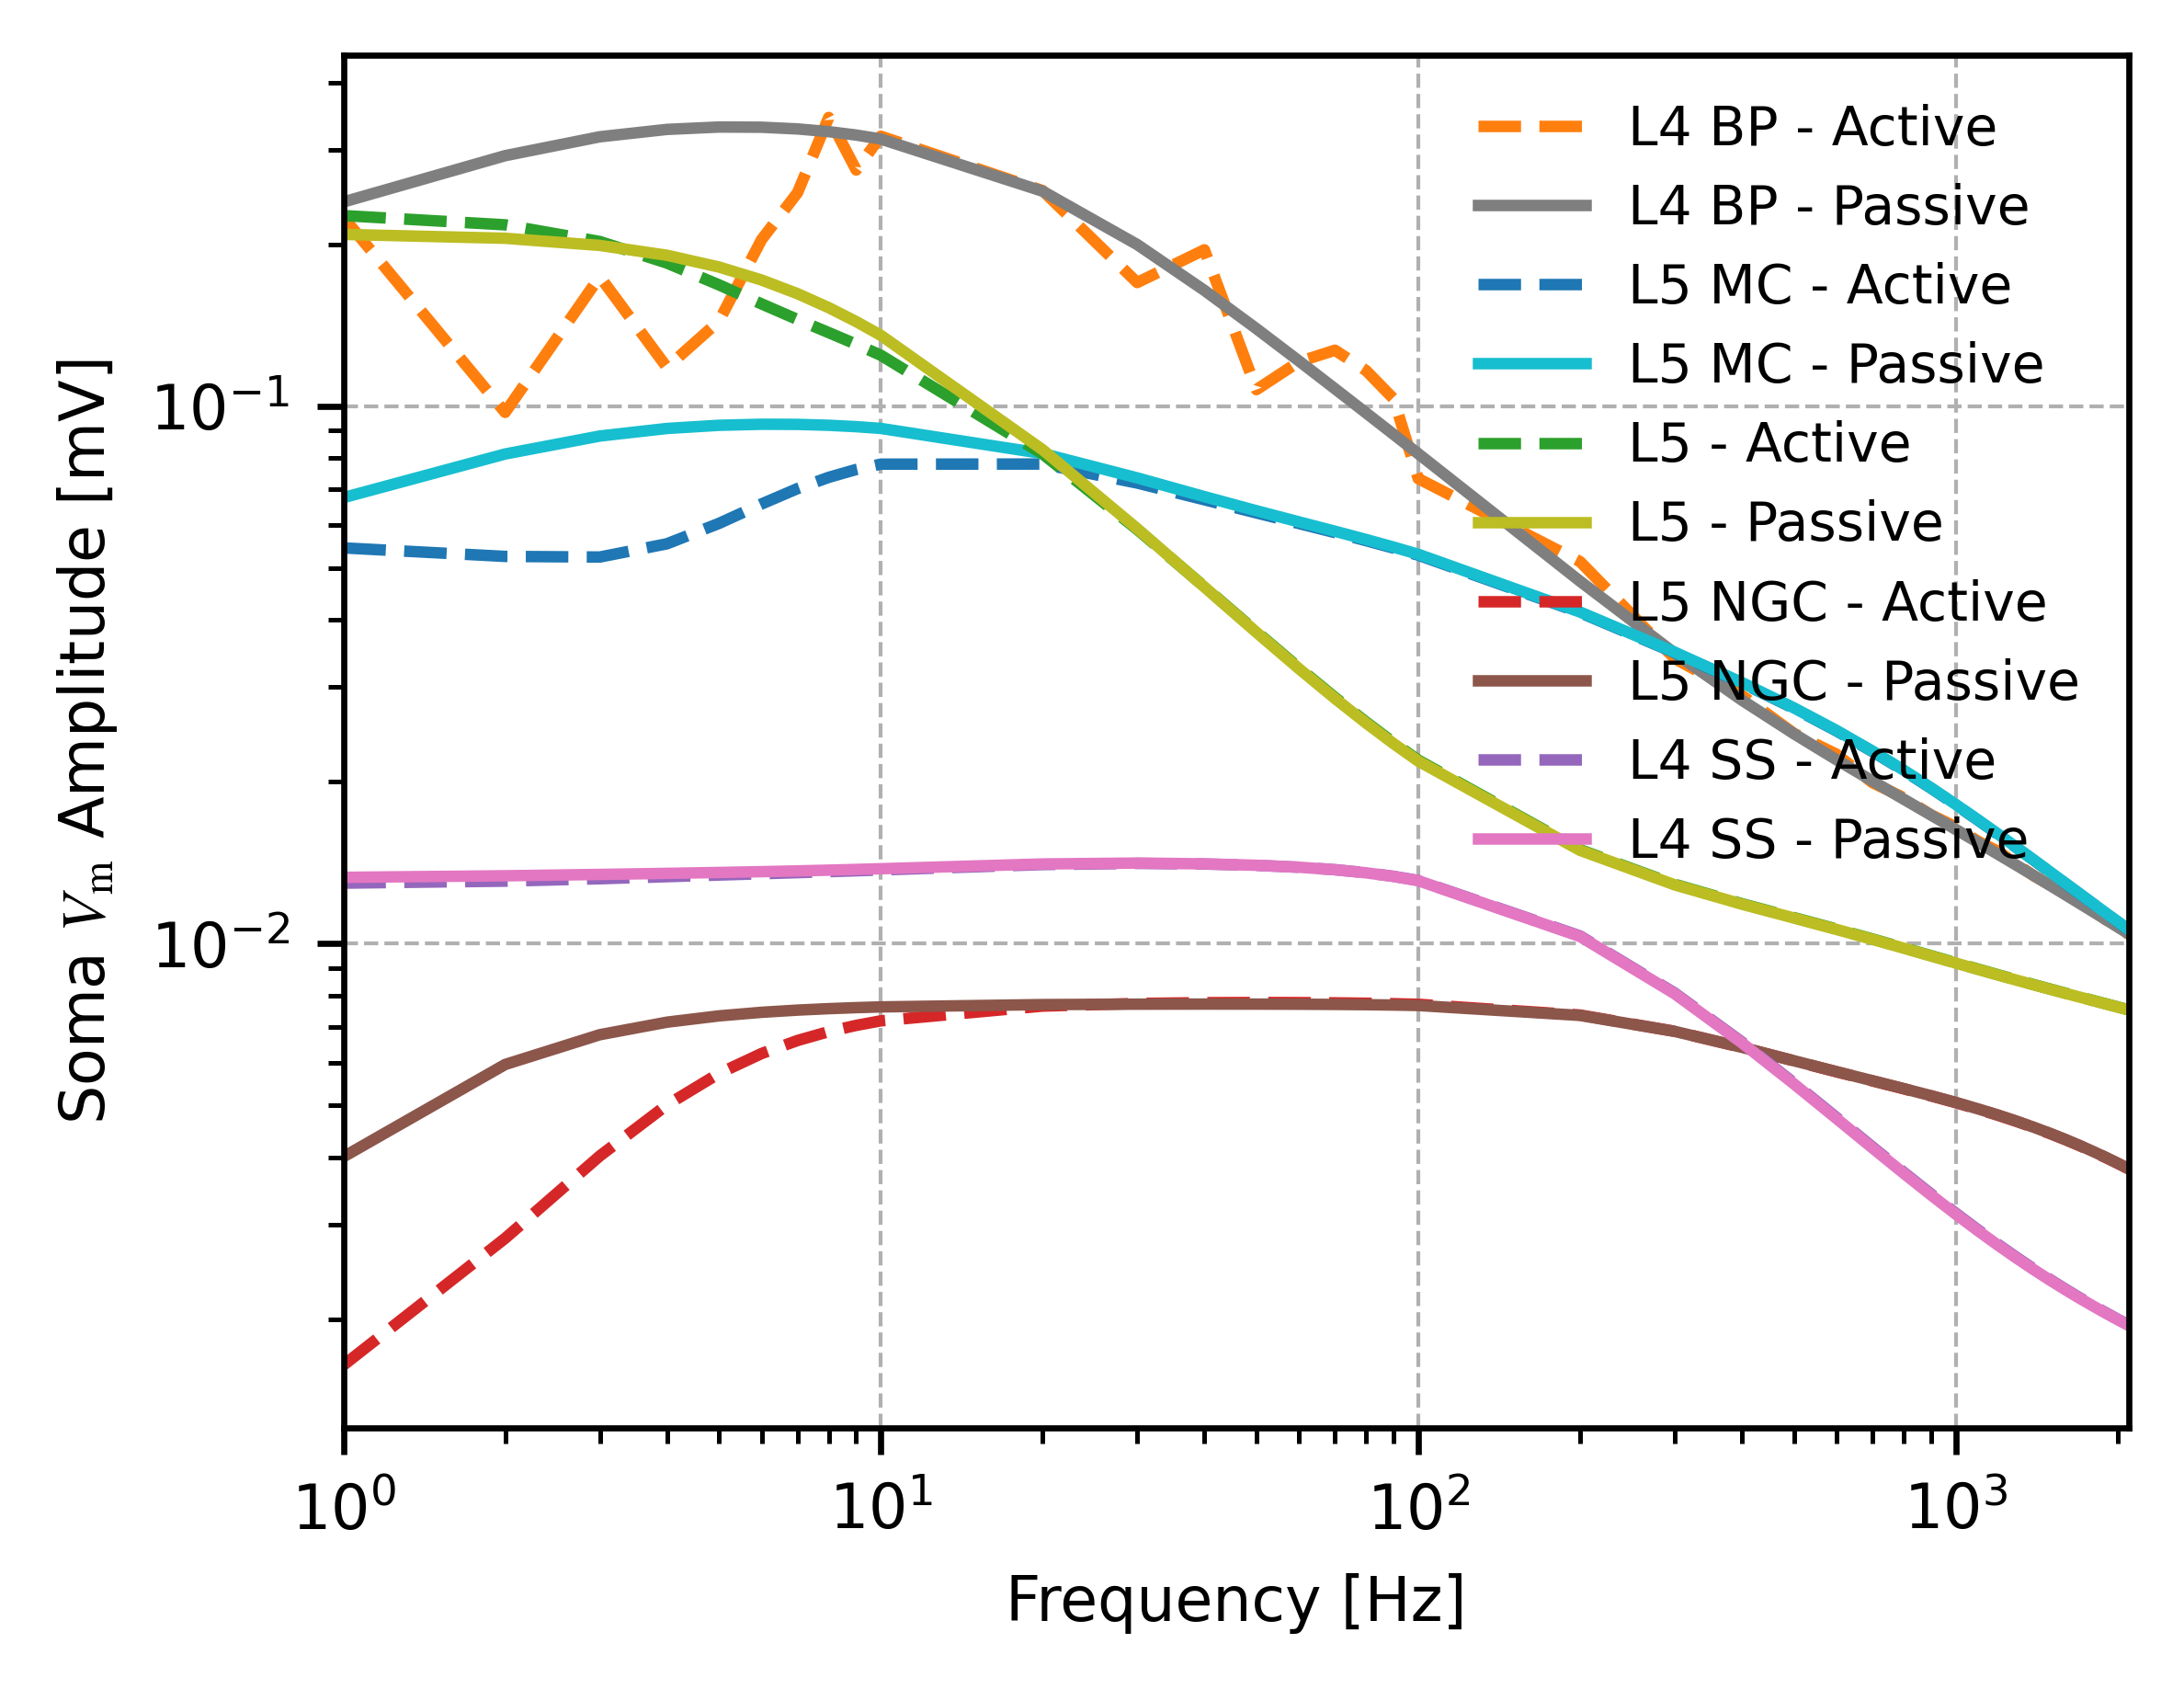

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

for cell_name, data in active_passive_dict.items():
    frequencies = data['freq']
    amplitudes = data ['soma_amps']

    base, state = cell_name.rsplit('_', 1)
    label = f"{cell_base[base]['name']} - {state.capitalize()}"

    if state == 'active':
        linestyle = '--'
        color = cell_base[base]['color_active']
    else:
        linestyle = '-'
        color = cell_base[base]['color_passive']

    ax.loglog(
        frequencies,
        amplitudes,
        label=label,
        color=color,
        linestyle = linestyle
    )

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Soma $V_\\mathrm{m}$ Amplitude [mV]')
ax.set_xlim(left=frequencies[0], right=frequencies[-1])
ax.grid(linestyle='--', linewidth=0.5)
ax.legend(loc='upper right', fontsize=7, frameon=False)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


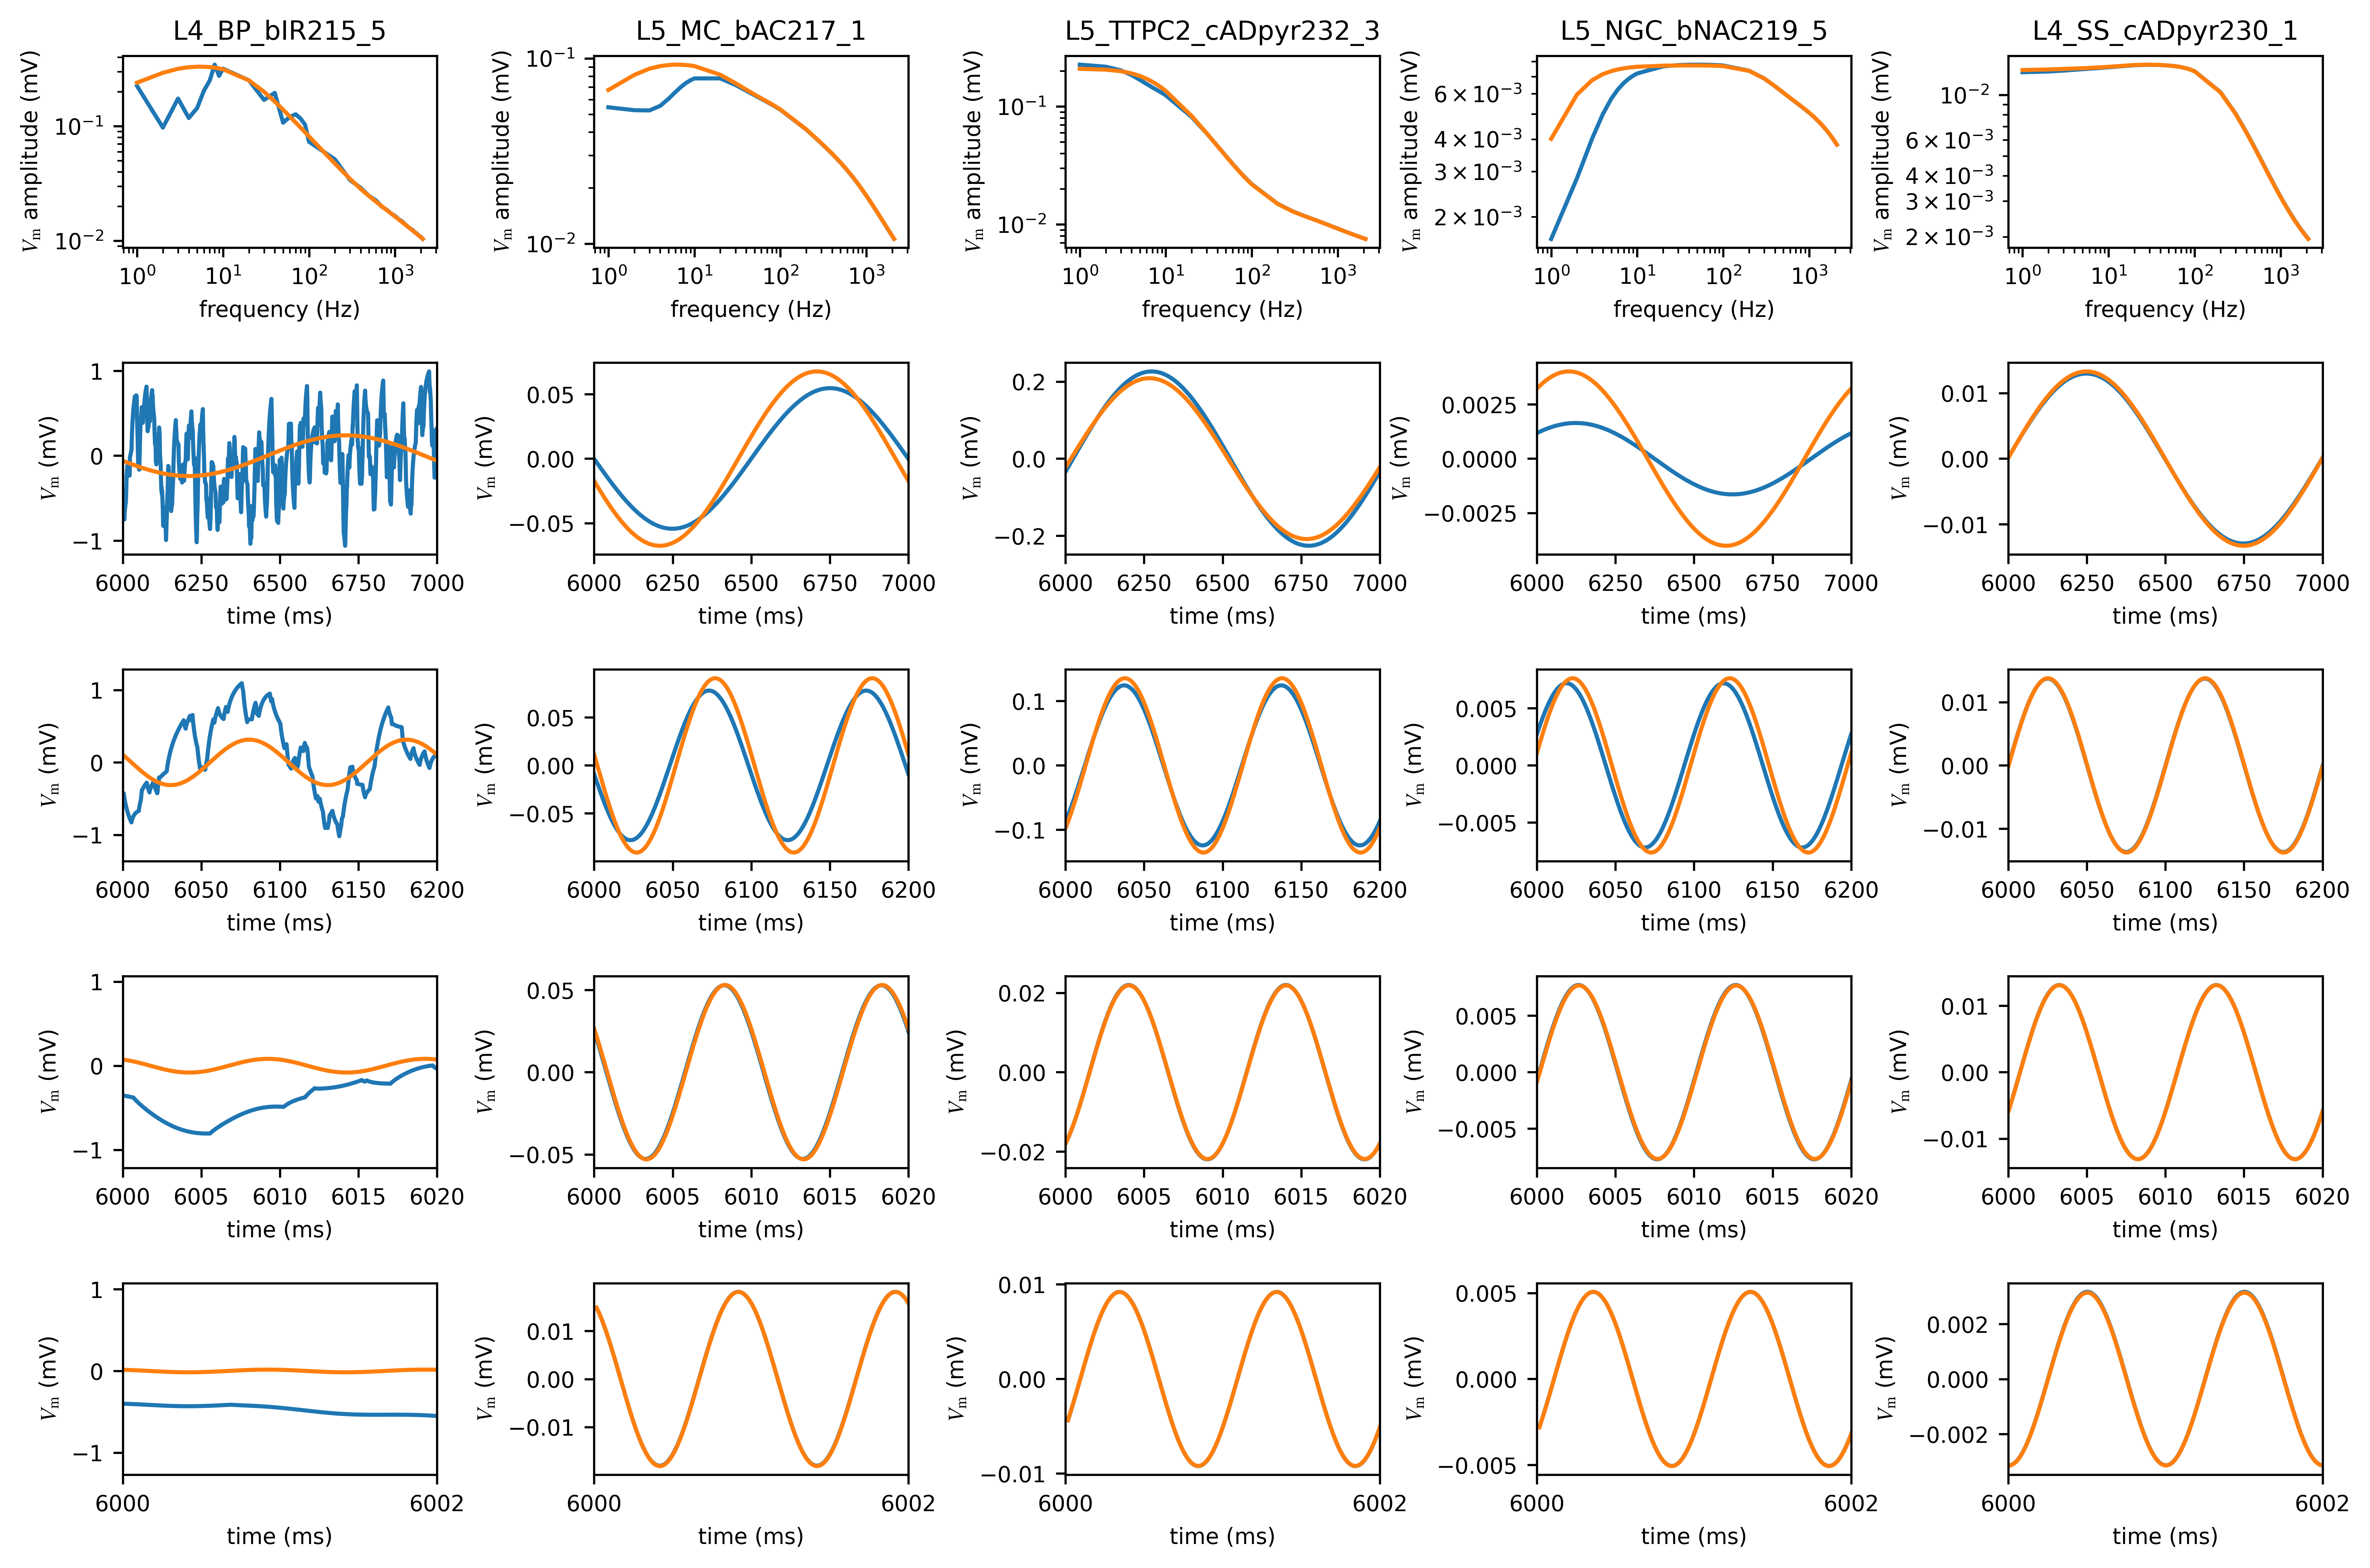

In [17]:
fig, ax = plt.subplots(5, len(selected_cells), figsize=(12, 8))
fig.subplots_adjust(wspace=0.5, hspace=0.6, top=0.95, bottom=0.05, left=0.05, right=0.98)

for ax_c in range(1, 5):
    [ax[ax_c, i].set_xlabel("time (ms)") for i in range(len(selected_cells))]
    [ax[ax_c, i].set_ylabel(r"$V_{\rm m}$ (mV)") for i in range(len(selected_cells))]

[ax[0, i].set_xlabel("frequency (Hz)") for i in range(len(selected_cells))]
[ax[0, i].set_ylabel(r"$V_{\rm m}$ amplitude (mV)") for i in range(len(selected_cells))]

for cell_numb, cell_name in enumerate(selected_cells):
    for c_type in ['active', 'passive']:
        t = active_passive_dict[f"{cell_name}_{c_type}"]["tvec"]
        v = active_passive_dict[f"{cell_name}_{c_type}"]["soma_vmem"]
        amp = active_passive_dict[f"{cell_name}_{c_type}"]["soma_amps"]
        stim_freq = np.array(active_passive_dict[f"{cell_name}_{c_type}"]["freq"])
        fourier_freq = active_passive_dict[f"{cell_name}_{c_type}"]["fourier_freq"]
        #print(stim_freq)
        #print(fourier_freq)

        f_idx_1Hz = np.argmin(np.abs(stim_freq - 1))
        f_idx_10Hz = np.argmin(np.abs(stim_freq - 10))
        f_idx_100Hz = np.argmin(np.abs(stim_freq - 100))
        f_idx_1000Hz = np.argmin(np.abs(stim_freq - 1000))

        ax[0, cell_numb].loglog(stim_freq, amp)
        ax[0, cell_numb].set_title(cell_name)
        
        ax[1, cell_numb].plot(t[f_idx_1Hz], v[f_idx_1Hz] - np.mean(v[f_idx_1Hz]))
        ax[1, cell_numb].set_xlim(6000, 7000)

        ax[2, cell_numb].plot(t[f_idx_10Hz], v[f_idx_10Hz] - np.mean(v[f_idx_10Hz]))
        ax[2, cell_numb].set_xlim(6000, 6200)

        ax[3, cell_numb].plot(t[f_idx_100Hz], v[f_idx_100Hz] - np.mean(v[f_idx_100Hz]))
        ax[3, cell_numb].set_xlim(6000, 6020)

        ax[4, cell_numb].plot(t[f_idx_1000Hz], v[f_idx_1000Hz] - np.mean(v[f_idx_1000Hz]))
        ax[4, cell_numb].set_xlim(6000, 6002)

        ax[4, cell_numb].set_xticks(ax[4, cell_numb].get_xticks()[::2])


#print(active_passive_dict[f"{cell_name}_{c_type}"].keys())
fig.savefig("active_passive_check.png")
fig.savefig("active_passive_check.pdf")